# Jet Radio Component: `RadioSpectrum`


In [1]:
import warnings
warnings.filterwarnings('ignore')

import jetset
print('tested with', jetset.__version__)

tested with 1.4.0rc3


In [2]:
%matplotlib inline

import numpy as np
from jetset.plot_sedfit import PlotSED
from jetset.jet_radio_component import RadioSpectrum

## Create the radio component and inspect parameters

In [3]:
radio = RadioSpectrum()
radio.show_model()
radio.show_pars()


--------------------------------------------------------------------------------
model description
--------------------------------------------------------------------------------
name: radio_spectrum  
type: radio_spectrum  

--------------------------------------------------------------------------------


name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
alpha_radio,spectral-slope,,0.000000e+00,-1.000000e+01,1.000000e+01,False,False
nu_ssa,turn-over freq,Hz,1.000000e+09,1.000000e+06,1.000000e+12,False,False
nu_cut,,Hz,1.000000e+11,1.000000e+06,1.000000e+13,False,False
nuFnu_p,flux-const,cm2 erg / s,1.000000e-13,1.000000e-30,1.000000e-05,False,False


--------------------------------------------------------------------------------


name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
alpha_radio,spectral-slope,,0.000000e+00,-1.000000e+01,1.000000e+01,False,False
nu_ssa,turn-over freq,Hz,1.000000e+09,1.000000e+06,1.000000e+12,False,False
nu_cut,,Hz,1.000000e+11,1.000000e+06,1.000000e+13,False,False
nuFnu_p,flux-const,cm2 erg / s,1.000000e-13,1.000000e-30,1.000000e-05,False,False


## Evaluate and plot the standalone spectrum

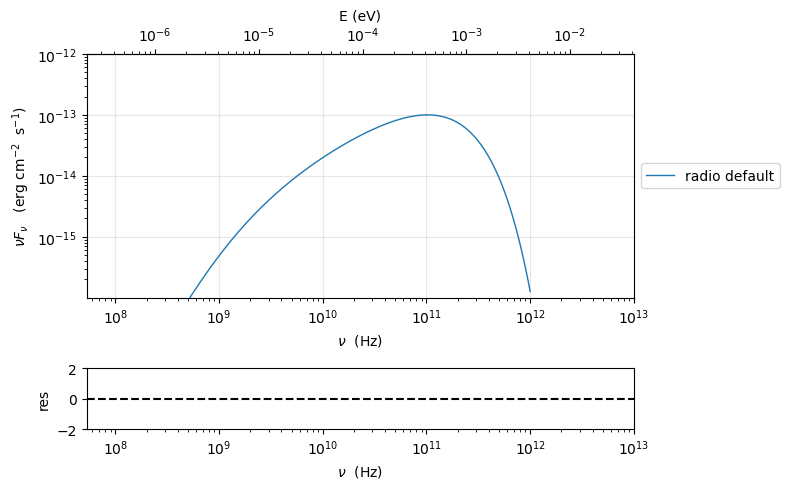

In [4]:
nu = np.logspace(6, 12, 250)
radio.eval(nu=nu, fill_SED=True)

p = PlotSED(figsize=(8, 5))
p.add_model_plot(radio.SED, label='radio default')
p.sedplot.grid(True, alpha=0.3)

## 3) Understand parameter effects

In [5]:
def plot_parameter_scan(parameter_name, values, title):
    p = PlotSED(figsize=(8, 5))
    for value in values:
        r = RadioSpectrum()
        getattr(r.parameters, parameter_name).val = value
        r.eval(nu=nu, fill_SED=True)
        p.add_model_plot(r.SED, label=f'{parameter_name}={value:.2e}')
    p.sedplot.set_title(title)
    p.sedplot.grid(True, alpha=0.3)
    return p

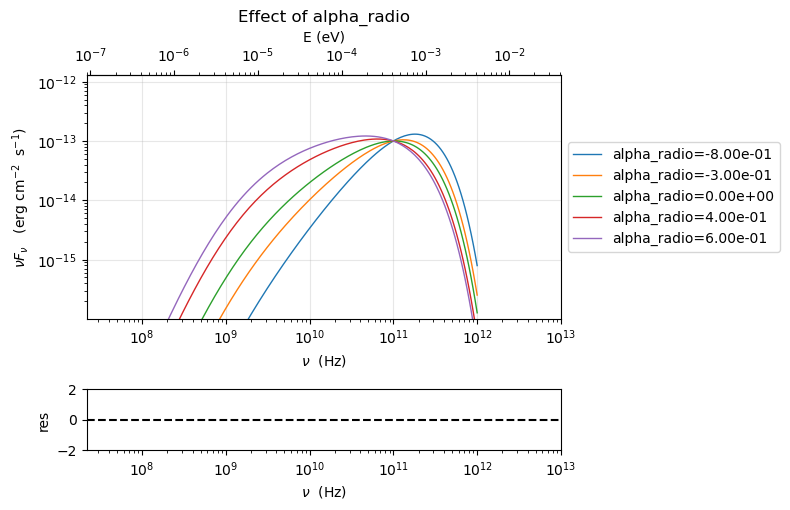

In [6]:
plot_parameter_scan('alpha_radio', [-0.8, -0.3, 0.0, 0.4, 0.6],
                    'Effect of alpha_radio')

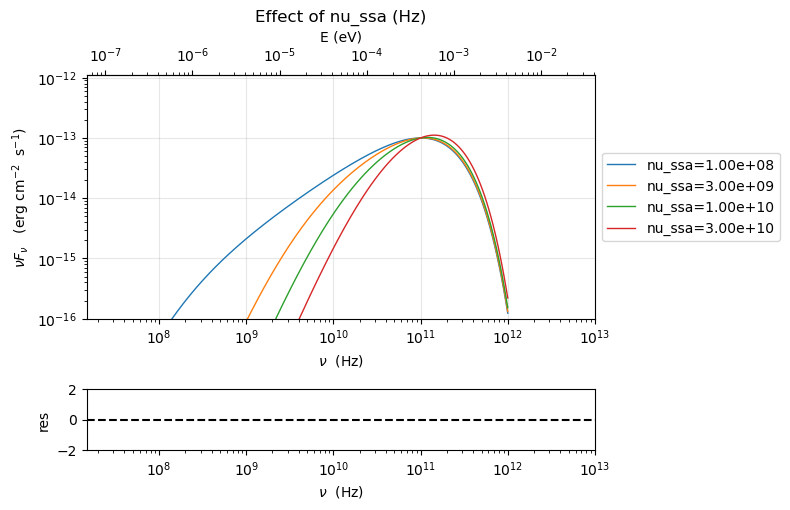

In [7]:
plot_parameter_scan('nu_ssa', [1e8, 3e9, 1e10, 3e10],
                    'Effect of nu_ssa (Hz)')

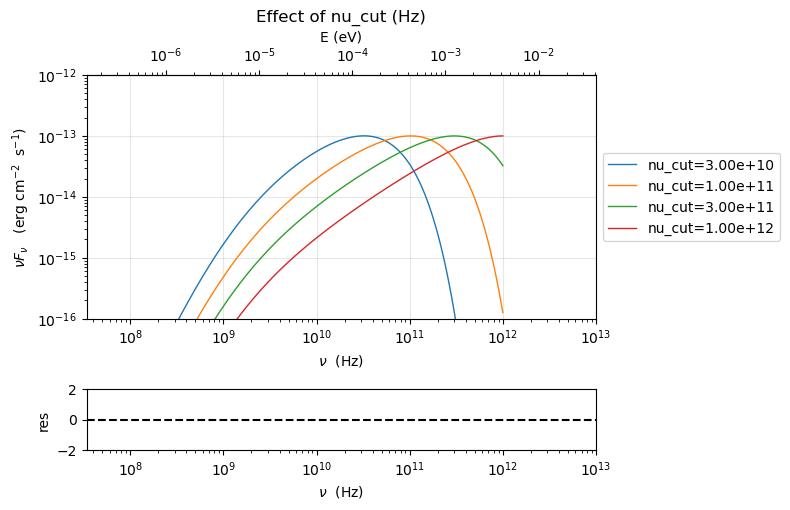

In [8]:
plot_parameter_scan('nu_cut', [3e10, 1e11, 3e11, 1e12],
                    'Effect of nu_cut (Hz)')

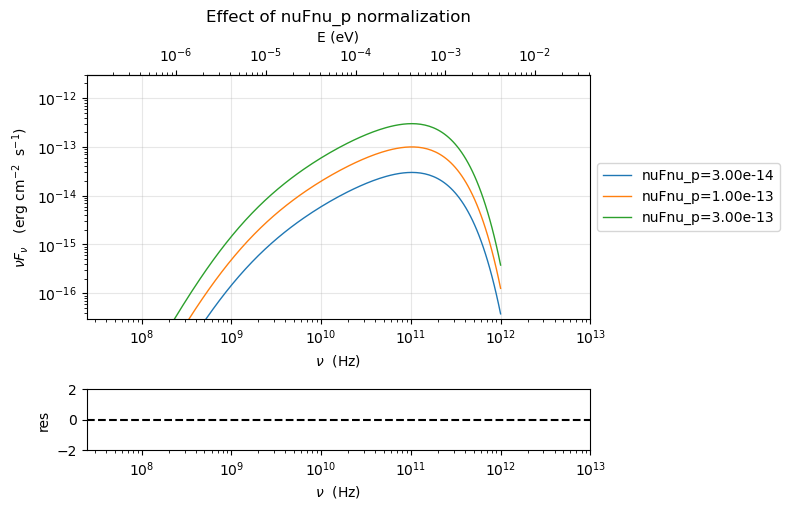

In [9]:
plot_parameter_scan('nuFnu_p', [3e-14, 1e-13, 3e-13],
                    'Effect of nuFnu_p normalization')

## 4) Combine `RadioSpectrum` with a jet model in `FitModel`

In [10]:
from jetset.jet_model import Jet
from jetset.model_manager import FitModel

jet = Jet()
jet.set_gamma_grid_size(100)
jet.set_N_from_nuFnu(nu_obs=1E12,nuFnu_obs=1E-13)
composite_model = FitModel(jet=jet, name='jet_plus_radio', template=None)
composite_model.add_component(RadioSpectrum())
composite_model.composite_expr = 'jet_leptonic+radio_spectrum'

composite_model.radio_spectrum.parameters.alpha_radio.val = 0.5
composite_model.radio_spectrum.parameters.nu_ssa.val = 1e8
composite_model.radio_spectrum.parameters.nu_cut.val = 2e10
composite_model.radio_spectrum.parameters.nuFnu_p.val = 5e-16

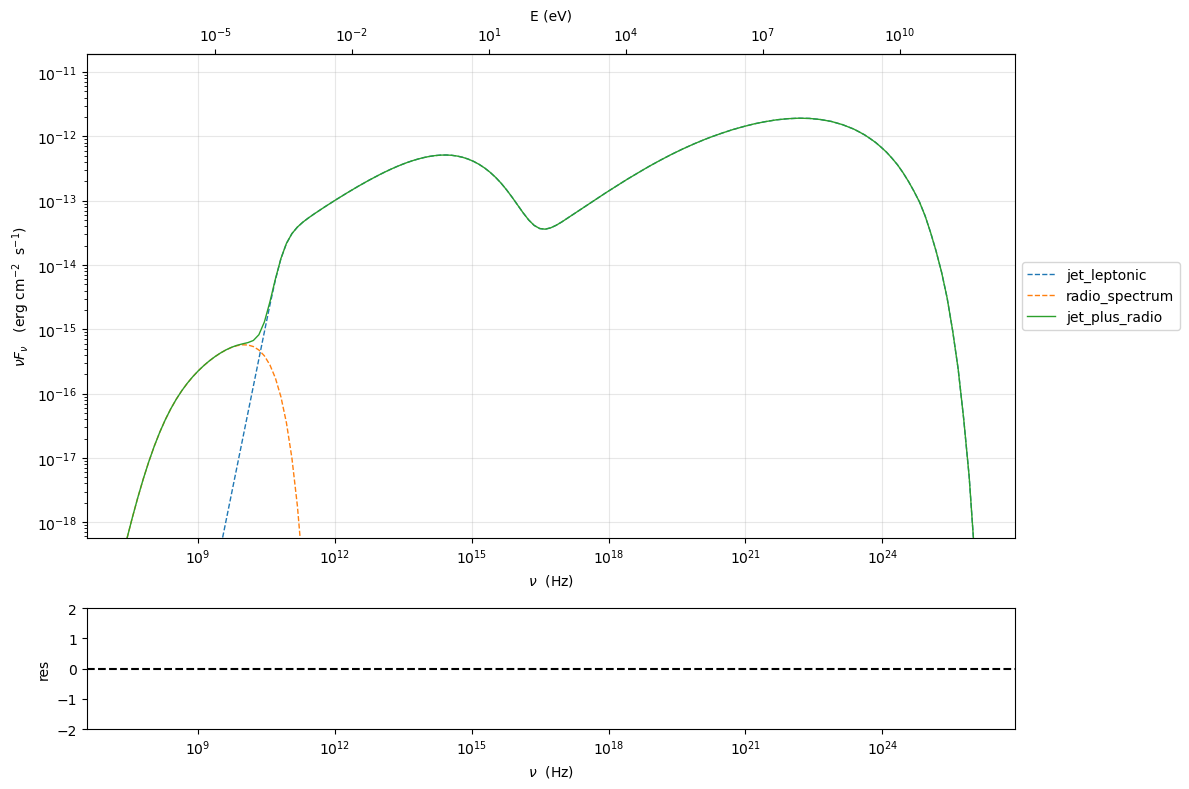

In [11]:
composite_model.eval()
plot_obj = composite_model.plot_model(skip_sub_components=True)
plot_obj.sedplot.grid(True, alpha=0.3)

In [12]:
composite_model.show_model_components()
composite_model.show_pars()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: jet_plus_radio  
type: composite_model  
components models:
 -model name: jet_leptonic model type: jet
 -model name: radio_spectrum model type: radio_spectrum

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,7.752460e+04,0.000000e+00,--,False,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,1.000000e+04,1.000000e+00,1.000000e+09,False,False


## 5) Typical fitting setup for the radio component

In [13]:
# A common approach before fitting:
composite_model.radio_spectrum.parameters.nu_ssa.frozen = True

# Leave normalization and cutoff free (example):
composite_model.radio_spectrum.parameters.alpha_radio.frozen = False
composite_model.radio_spectrum.parameters.nuFnu_p.frozen = False
composite_model.radio_spectrum.parameters.nu_cut.frozen = False
composite_model.show_pars()

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,7.752460e+04,0.000000e+00,--,False,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,1.000000e+04,1.000000e+00,1.000000e+09,False,False
